# Global forcing maps — Figure 1

Time-averaged global distributions (2000-2019) of the four fields shown in
Figure 1 of the manuscript:

1. (a) Mean temperature in the epipelagic layer
2. (b) Mean vertically integrated net primary production
3. (c) Mean current norm $\sqrt{u^2 + v^2}$ in the epipelagic layer
4. (d) Mean zooplankton biomass from the SEAPODYM-LMTL reference simulation

Inputs: `data/forcings_global.zarr`.
Output: `figures/Figure_1.{pdf,png}`.
Runtime: ~5-10 minutes (depends on disk I/O for ~6 GB of forcings).

In [1]:
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr


def _project_root(marker: str = "pyproject.toml") -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Project root marker {marker!r} not found.")


PROJECT_ROOT = _project_root()
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

ANALYSIS_START = "2000-01-01"
ANALYSIS_END = "2019-12-31"

## Climatologies (2000-2019)

In [2]:
ds = xr.open_zarr(DATA_DIR / "forcings_global.zarr").sel(T=slice(ANALYSIS_START, ANALYSIS_END))

temperature_mean = ds.temperature.mean("T", skipna=False).compute()
npp_mean = ds.npp.mean("T", skipna=False).compute()
zooc_mean = ds.zooc.mean("T", skipna=False).compute()
current_norm_mean = np.sqrt(ds.U**2 + ds.V**2).mean("T", skipna=False).compute().rename("current_norm")

## Add a cyclic longitude point to close the globe

In [3]:
def add_cyclic_point(da: xr.DataArray, lon_name: str = "X") -> xr.DataArray:
    extra = da.isel({lon_name: 0})
    out = xr.concat([da, extra], dim=lon_name)
    return out.assign_coords({lon_name: list(da[lon_name].values) + [180]})


temperature_mean = add_cyclic_point(temperature_mean)
npp_mean = add_cyclic_point(npp_mean)
zooc_mean = add_cyclic_point(zooc_mean)
current_norm_mean = add_cyclic_point(current_norm_mean)

## Figure 1 — four-panel global map

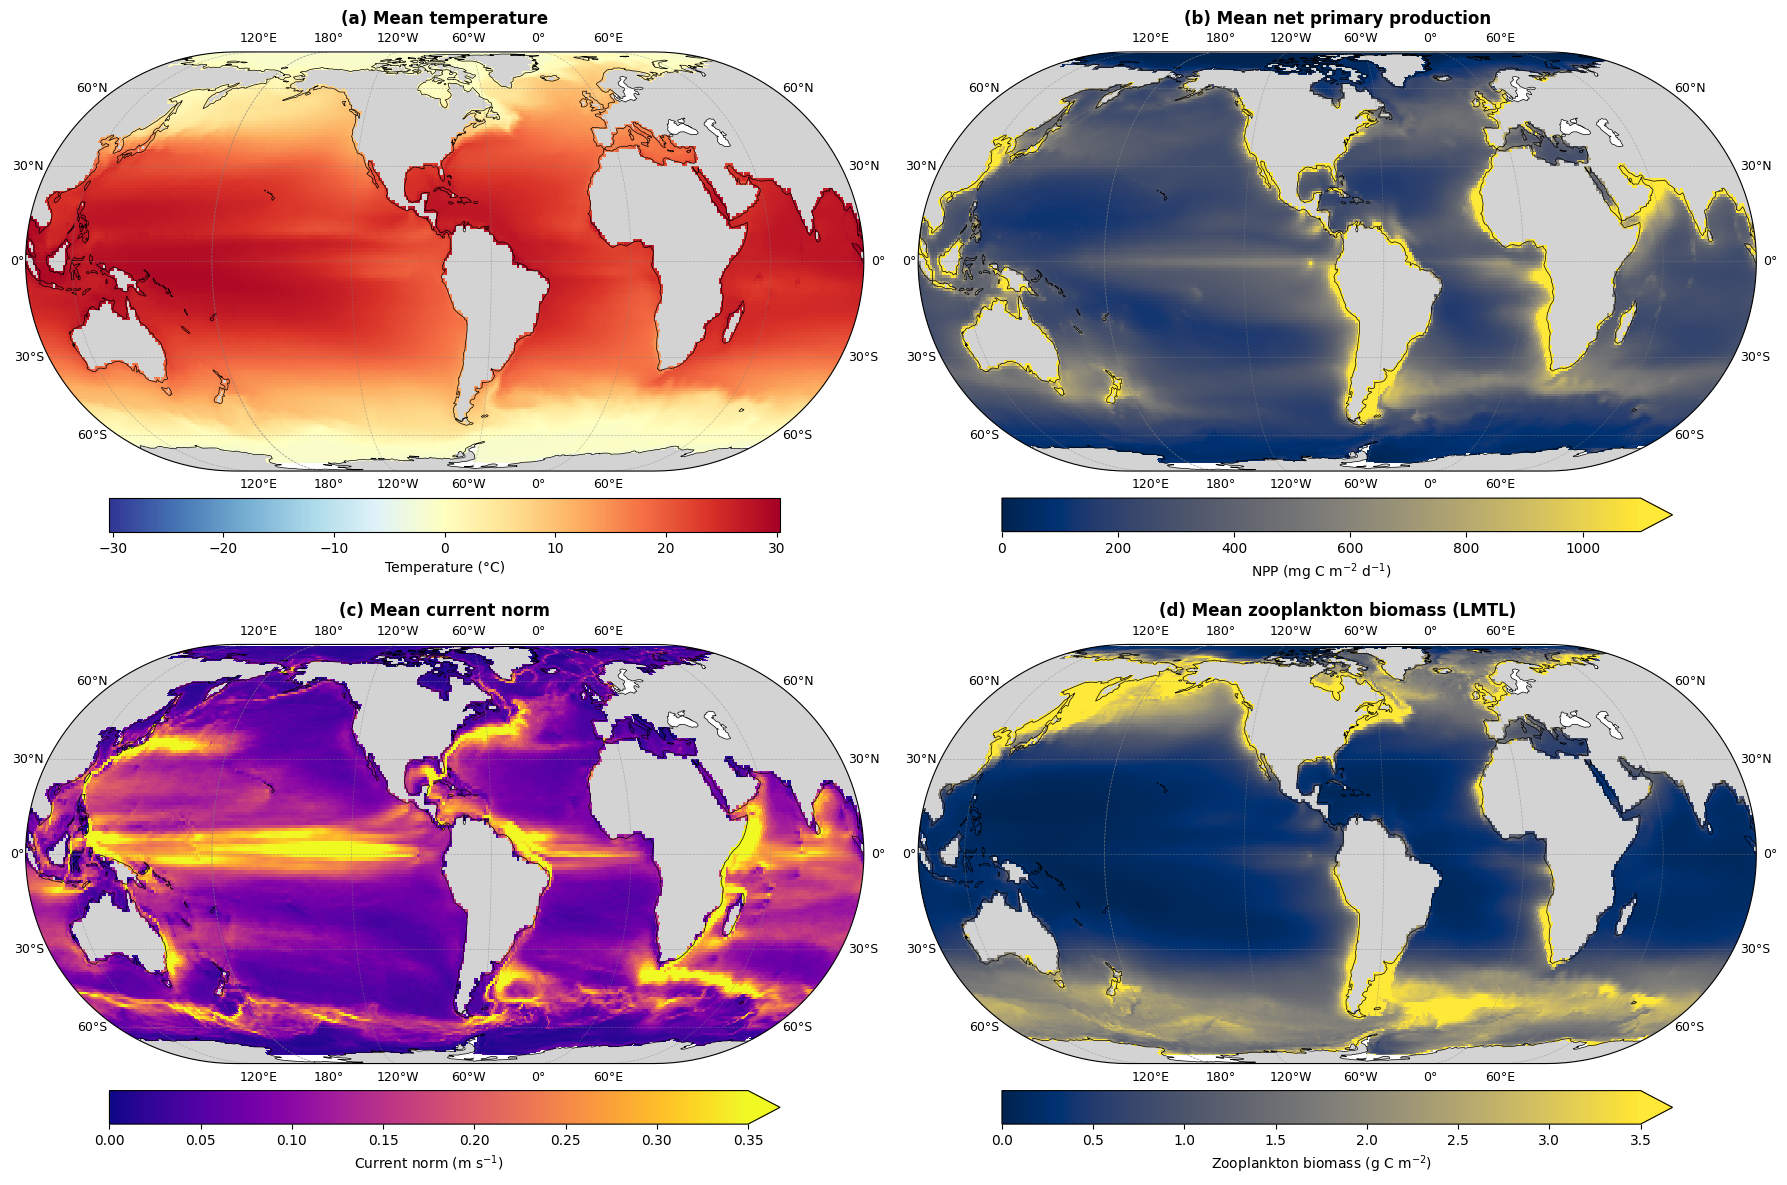

In [4]:
PANELS = [
    {"data": temperature_mean,   "cmap": "RdYlBu_r", "vmin": None, "vmax": None, "label": "Temperature (°C)",                              "title": "(a) Mean temperature"},
    {"data": npp_mean,           "cmap": "cividis",  "vmin": 0,    "vmax": 1100, "label": r"NPP (mg C m$^{-2}$ d$^{-1}$)",                  "title": "(b) Mean net primary production"},
    {"data": current_norm_mean,  "cmap": "plasma",   "vmin": 0,    "vmax": 0.35, "label": r"Current norm (m s$^{-1}$)",                     "title": "(c) Mean current norm"},
    {"data": zooc_mean,          "cmap": "cividis",  "vmin": 0,    "vmax": 3.5,  "label": r"Zooplankton biomass (g C m$^{-2}$)",            "title": "(d) Mean zooplankton biomass (LMTL)"},
]

fig, axes = plt.subplots(
    2, 2, figsize=(18, 12),
    subplot_kw={"projection": ccrs.EckertIV(central_longitude=-80)},
)

for ax, panel in zip(axes.flat, PANELS):
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="black", zorder=2)
    m = panel["data"].plot(
        ax=ax, transform=ccrs.PlateCarree(),
        cmap=panel["cmap"], vmin=panel["vmin"], vmax=panel["vmax"],
        add_colorbar=False, zorder=1,
    )
    ax.gridlines(
        draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--",
        x_inline=False, y_inline=False,
        xlabel_style={"size": 9}, ylabel_style={"size": 9},
    )
    cbar = plt.colorbar(m, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8, extend="max" if panel["vmax"] is not None else "neither")
    cbar.set_label(panel["label"], fontsize=10)
    ax.set_title(panel["title"], fontsize=12, fontweight="bold")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "Figure_1.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "Figure_1.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()